In [261]:
# Cell 1: Imports
import numpy as np
import importlib
import csv
import os
import matplotlib.pyplot as plt
from pybaselines.whittaker import asls
from scipy.signal import find_peaks
import functions as functions
from functions import shift_spectrum_to_peak
from functions import calculate_fitted_peak_area
importlib.reload(functions)
%matplotlib widget


In [262]:
# Cell 2: Load XRD data function
def load_XRD_txt(file_path):
    """
    Loads XRD data from a .txt file.
    Assumes two columns: 2theta, intensity.
    """
    data = np.loadtxt(file_path, comments="#", delimiter=None)
    two_theta = data[:, 0]
    intensity = data[:, 1]
    return two_theta, intensity

In [263]:
# Cell 3: Background subtraction function
def subtract_background(intensity, lam=1e5, p=0.0001):
    """
    Subtracts background using Asymmetric Least Squares (AsLS).
    Returns baseline and background-subtracted intensity.
    """
    baseline = asls(intensity, lam=lam, p=p)[0]
    corrected = intensity - baseline
    return baseline, corrected

In [264]:
# Cell 4: Normalization function
def normalize_to_peak(two_theta, intensity, peak_center=37.9, window=0.2):
    """
    Normalizes intensity to the maximum value within a small window around a given 2θ peak.
    """
    mask = (two_theta > peak_center - window) & (two_theta < peak_center + window)
    peak_intensity = intensity[mask].max()
    normalized_intensity = intensity / peak_intensity
    return normalized_intensity


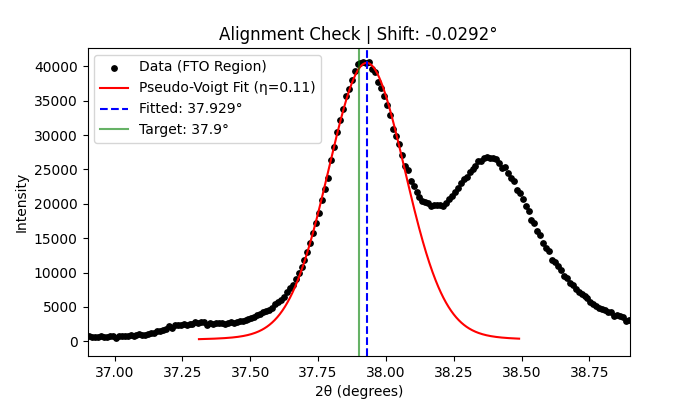

test 2
2θ shift applied: -0.0292 degrees


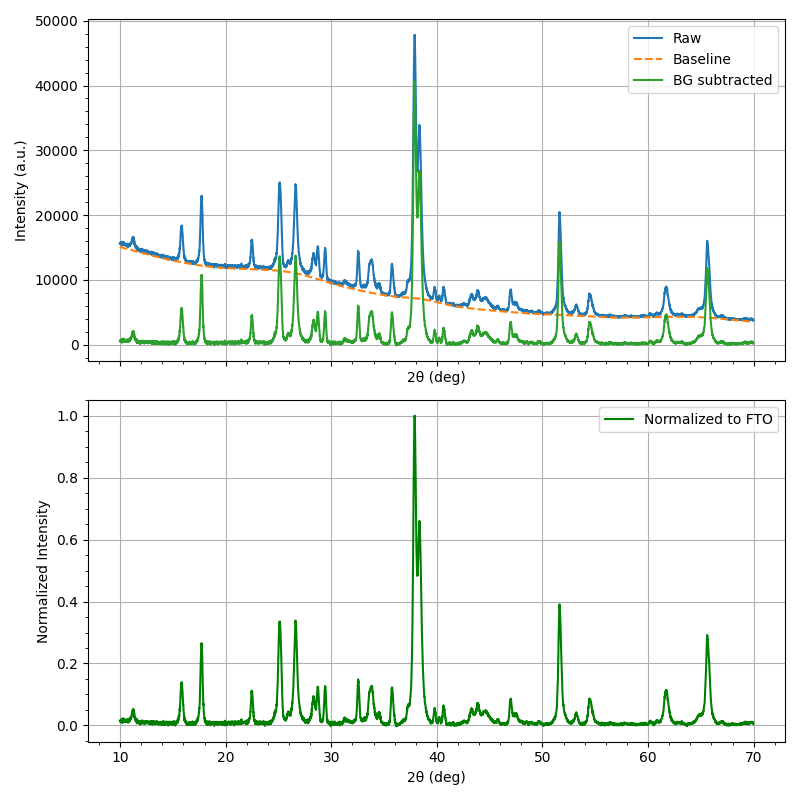

In [265]:
# Cell 5: Load, process, and plot
file_path = r"..\data\raw_data\second_batch\3_14_07_OTA_1.xy"
two_theta, intensity = load_XRD_txt(file_path)

# Background subtraction
baseline, corrected = subtract_background(intensity, lam=1e6, p=0.0001)

# Normalization to FTO peak at 37.9°
normalized_intensity = normalize_to_peak(two_theta, corrected, peak_center=37.9, window=0.2)

# Shift the spectrum to align the FTO peak at 37.9°
two_theta, shift = shift_spectrum_to_peak(two_theta, corrected, target_peak=37.9, window=0.2, plot=True)
print(f"2θ shift applied: {shift:.4f} degrees")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8), sharex=True)

# Top: raw and background-subtracted
ax1.plot(two_theta, intensity, label="Raw")
ax1.plot(two_theta, baseline, '--', label="Baseline")
ax1.plot(two_theta, corrected, label="BG subtracted")
ax1.set_xlabel("2θ (deg)")
ax1.set_ylabel("Intensity (a.u.)")
ax1.legend()
ax1.minorticks_on()
ax1.grid(True)

# Bottom: normalized_intensity
ax2.plot(two_theta, normalized_intensity, label="Normalized to FTO", color='green')
ax2.set_xlabel("2θ (deg)")
ax2.set_ylabel("Normalized Intensity")
ax2.legend()
ax2.minorticks_on()
ax2.grid(True)

plt.tight_layout()
plt.show()



In [266]:
# Cell 6: Save processed data

# Create the processed_data folder if it doesn't exist
output_folder = "processed_data"
os.makedirs(output_folder, exist_ok=True)

# Extract the base name of the input file (without extension)
input_file_name = os.path.basename(file_path)
output_file_name = os.path.splitext(input_file_name)[0] + "_processed.txt"

# Combine the folder and file name to create the full output path
output_file_path = os.path.join(output_folder, output_file_name)

# Save the raw data, baseline, corrected, normalized, and two_theta
processed_data = np.column_stack((two_theta, intensity, baseline, corrected, normalized_intensity))
np.savetxt(output_file_path, processed_data, 
           header="2theta\tintensity\tbaseline\tbg_subtracted\tnormalized", 
           fmt="%.5f")

print(f"Processed data saved to '{output_file_path}'")


Processed data saved to 'processed_data\3_14_07_OTA_1_processed.txt'


In [267]:
# Cell 7: Define peaks and JCPDS intensities and define function to get peak intensity
# Format: 2theta (deg): relative intensity
peaks = {
    "020/200": (15.7, 57+21),
    "121/211": (29.4, 45+82),
}

--- Processing Peaks for 3_14_07_OTA_1.xy ---
Fitting 020/200 near 15.7°...


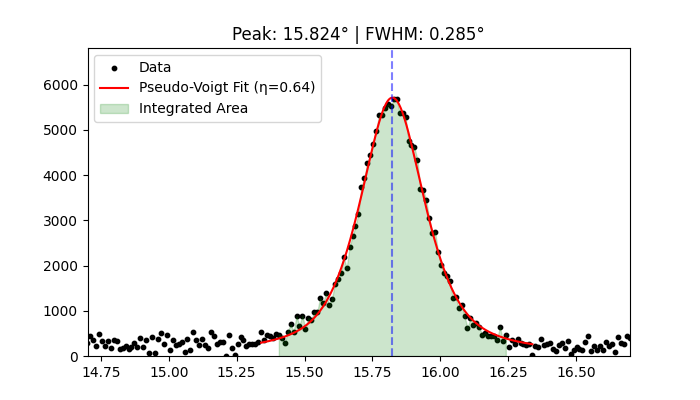

 > Success: Area = 1921.97, FWHM = 0.285
Fitting 121/211 near 29.4°...


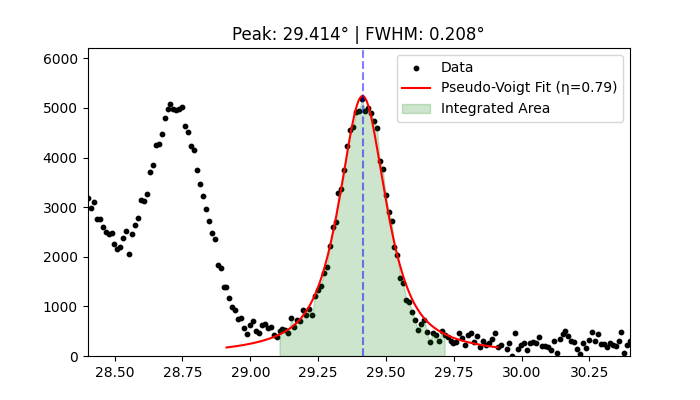

 > Success: Area = 1284.78, FWHM = 0.208

Final Peak Summary:
020/200: Area=1922.0, Ref_I0=78
121/211: Area=1284.8, Ref_I0=127


In [268]:
# 1. Load the data using NumPy
# Column 0: 2theta, Column 3: bg_subtracted (corrected)
data = np.loadtxt(output_file_path, skiprows=1)
two_theta_col = data[:, 0]
intensity_col = data[:, 3] 


# Dictionary to store our results for TC calculation later
calculated_results = {}

print(f"--- Processing Peaks for {input_file_name} ---")

for name, (pos, i0) in peaks.items():
    print(f"Fitting {name} near {pos}°...")
    
    # We use a search window of ±0.5° around the target peak position to find the actual peak in the data
    area, fwhm = calculate_fitted_peak_area(
        two_theta_col, 
        intensity_col, 
        target_peak=pos, 
        search_window=0.5, 
        plot=True
    )
    
    if area > 0:
        calculated_results[name] = {
            "measured_area": area,
            "reference_i0": i0,
            "fwhm": fwhm
        }
        print(f" > Success: Area = {area:.2f}, FWHM = {fwhm:.3f}")
    else:
        print(f" > Warning: Could not fit peak {name}")

# 3. Quick check of the results
print("\nFinal Peak Summary:")
for name, res in calculated_results.items():
    print(f"{name}: Area={res['measured_area']:.1f}, Ref_I0={res['reference_i0']}")

In [269]:
# Extract and normalize with JCPDS reference intensities
norm_hk0 = calculated_results["020/200"]["measured_area"] / peaks["020/200"][1]
norm_hk1 = calculated_results["121/211"]["measured_area"] / peaks["121/211"][1]

# Final TC Ratio (hk1 relative to hk0)
tc_ratio = norm_hk1 / norm_hk0

print(f"Sample: {input_file_name} | TC Ratio (121)/(211) vs. (020)/(200): {tc_ratio:.3f}")

Sample: 3_14_07_OTA_1.xy | TC Ratio (121)/(211) vs. (020)/(200): 0.411


In [270]:
# 1. Prepare the data for storage
# We use the actual plane names from your 'peaks' dictionary keys
plane_names = list(peaks.keys()) # ['(020)/(200)', '(121)/(211)']
ratio_column_name = f"Ratio_{plane_names[1]}_vs_{plane_names[0]}"

# 2. Print Summary to Console
print(f"--- Results for {input_file_name} ---")
for hkl, res in calculated_results.items():
    print(f"Peak {hkl}: Pos={res['fwhm']:.3f}, Area={res['measured_area']:.2f}")

print(f"Final TC Ratio ({ratio_column_name}): {tc_ratio:.5f}")

# 3. Define the output file name (Excel-compatible CSV)
output_csv_file = "texture_coefficient_ratios.csv"
file_exists = os.path.isfile(output_csv_file)

# 4. Save to File
with open(output_csv_file, mode="a", newline="") as file:
    writer = csv.writer(file)
    
    # Write the header only if the file is new
    if not file_exists:
        # Header: File, Ratio_121/211_vs_020/200
        writer.writerow(["File", ratio_column_name])
    
    # Write the sample row
    writer.writerow([input_file_name, f"{tc_ratio:.5f}"])

print(f"Successfully appended results to {output_csv_file}")

--- Results for 3_14_07_OTA_1.xy ---
Peak 020/200: Pos=0.285, Area=1921.97
Peak 121/211: Pos=0.208, Area=1284.78
Final TC Ratio (Ratio_121/211_vs_020/200): 0.41055
Successfully appended results to texture_coefficient_ratios.csv
